# BBBC021

MCF-7 breast cancer cells treated with 113 small molecules {cite:p}`Caie_2010`,
and the standard mechanism-of-action benchmark {cite:p}`Ljosa_2013`.
{func}`~mantispy.ds.bbbc021` returns the subset the benchmark annotates: 38 compounds and DMSO, 103 treatments
across 12 mechanisms.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import mantispy as mt

adata = mt.ds.bbbc021()
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/ETcli4Pw/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 632 × 467
    obs: 'Metadata_Plate', 'Metadata_Well', 'Metadata_Compound', 'Metadata_Concentration', 'Metadata_MOA', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_Control', 'Metadata_Perturbation'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

## Source

| file | from | holds |
| --- | --- | --- |
| `ljosa_2013.csv` | Cell Painting Gallery, `cpg0010-caie-drugresponse/broad-az/workspace/backend` | the well-level CellProfiler profiles |
| `BBBC021_v1_image.csv` | Broad Bioimage Benchmark Collection {cite:p}`Ljosa_2012` | compound and concentration per plate and well |
| `BBBC021_v1_moa.csv` | Broad Bioimage Benchmark Collection | the mechanism per compound and concentration |
| 632 × `Image.csv` | Cell Painting Gallery, `workspace/analysis/<week>/<plate>/analysis/<plate>-<well>` | one row per field of view, with its cell count |

Every file is pinned by sha256 in the registry.

## Columns mantispy adds

| column | how |
| --- | --- |
| `Metadata_Compound`, `Metadata_Concentration` | `BBBC021_v1_image.csv`, joined on plate and well |
| `Metadata_MOA` | `BBBC021_v1_moa.csv`, joined on compound and concentration |
| `Metadata_Control` | `Metadata_Compound == "DMSO"` |
| `Metadata_Perturbation` | compound and concentration, `"<compound>@<concentration>"`: what replicate wells share |
| `Metadata_CellCount` | `Count_Cells` of the well's `Image.csv`, summed over its fields |
| `Metadata_SiteCount` | the fields of that `Image.csv` that contributed cells |

The `Image.csv` files are from the same CellProfiler run as the profiles, which the profiles themselves show.
CellProfiler numbers the cells of each field from 1, so a field of $n$ cells contributes object numbers $1, \dots, n$,
and a well's mean `Cells_Number_Object_Number` is fixed by its per-field counts $n_s$:

$$\frac{\sum_s n_s (n_s + 1) / 2}{\sum_s n_s}$$

In [2]:
cache = mt.settings.cache_dir / "mantispy"
profiles = pd.read_csv(cache / "ljosa_2013__analysis_batch_stable__ljosa_2013.csv").set_index(
    ["Image_Metadata_Plate", "Image_Metadata_Well"]
)["Cells_Number_Object_Number"]

checked = []
for path in sorted(cache.glob("cpg0010-caie-drugresponse/**/Image.csv")):
    n = pd.read_csv(path, usecols=["Count_Cells"])["Count_Cells"].to_numpy()
    plate, well = path.parent.name.rsplit("-", 1)
    checked.append((plate, well, (n * (n + 1) / 2).sum() / n.sum(), profiles[(plate, well)]))
checked = pd.DataFrame(checked, columns=["plate", "well", "from Image.csv", "in the profiles"])
agree = np.isclose(checked["from Image.csv"], checked["in the profiles"])
print(f"{agree.sum()} of {len(checked)} wells agree exactly")
checked.assign(difference=checked["in the profiles"] - checked["from Image.csv"])[~agree].head()

607 of 632 wells agree exactly


,plate,well,from Image.csv,in the profiles,difference
89,Week1_22401,E07,133.151679,132.958785,-0.192894
116,Week10_40115,D05,110.201258,110.444724,0.243466
124,Week10_40119,C06,31.009569,30.860577,-0.148992
143,Week2_24121,G03,41.046296,40.919505,-0.126792
145,Week2_24141,B02,96.478029,96.586436,0.108407


In the other 25 wells the two differ by at most 1.5.
Those wells' profiles averaged over nearly, but not exactly, the cells CellProfiler counted.
For `Week2_24121` well G03, the analysis run's `Cells.csv` holds exactly the 324 cells its `Image.csv` counts, and
their mean object number is the 41.05 the counts give, against 40.92 in the profile.
`Metadata_CellCount` is CellProfiler's count either way.

## What it looks like

Cell count is the first thing many mechanisms change.
Microtubule stabilizers and destabilizers, DNA replication inhibitors and Eg5 inhibitors all stop cells dividing, and
leave a third to two fifths of the cells a DMSO well holds; the kinase inhibitors leave more than DMSO.
A profile's distance from the controls has to be read beside this, which is what {func}`~mantispy.tl.cytotoxicity`
does.

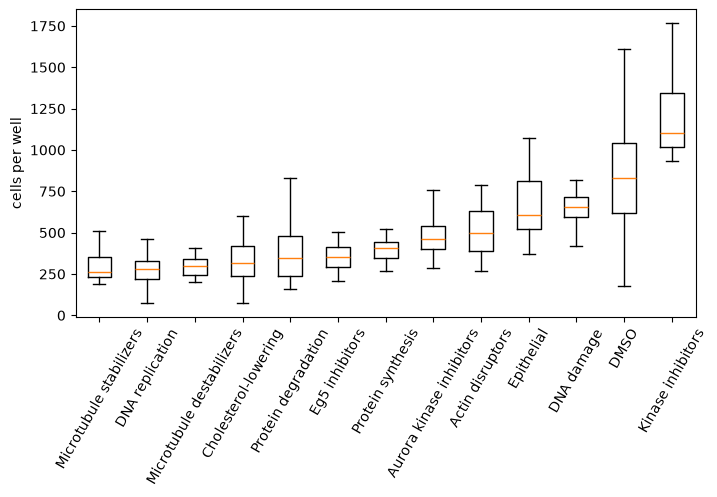

In [3]:
obs = adata.obs
order = obs.groupby("Metadata_MOA", observed=True)["Metadata_CellCount"].median().sort_values().index
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [obs.loc[obs["Metadata_MOA"] == moa, "Metadata_CellCount"] for moa in order],
    tick_labels=list(order),
    showfliers=False,
)
ax.set_ylabel("cells per well")
ax.tick_params(axis="x", rotation=60)